In [2]:
import pandas as pd

df = pd.read_csv("reduced_dataset.csv")
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,17742,200000,2,3,2,63,-1,3,2,-1,...,316,316,316,0,0,316,316,316,316,1
1,4625,240000,2,2,1,37,0,-1,-1,0,...,1932,7363,1546,1346,3195,0,7383,1546,4390,0
2,1737,80000,2,2,2,29,2,0,0,0,...,67972,66800,68693,2661,2509,2500,3000,3000,3000,1
3,28197,360000,2,2,1,40,-1,-1,-1,-1,...,41301,10889,2017,27930,692,41303,10893,2017,13894,0
4,19220,300000,2,3,1,34,-2,-2,-2,-2,...,-20,-20,4045,29089,21286,0,0,4065,0,0


In [3]:
df.shape

(4000, 25)

In [4]:
#Check dataset
print(df.shape)
print(df.columns)

(4000, 25)
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='object')


In [17]:
# ==============================
# STEP 1: IMPORT LIBRARY
# ==============================
import pandas as pd


# ==============================
# STEP 2: LOAD DATASET
# ==============================
df = pd.read_csv("reduced_dataset.csv")

print("Dataset Loaded!")
print("Shape:", df.shape)


# ==============================
# STEP 3: CLEAN DATA
# ==============================
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])


# ==============================
# STEP 4: APPLY CSP (0/1 CONSTRAINTS)
# ==============================
c1 = []  # Late Payment
c2 = []  # Low Limit
c3 = []  # High Bill
c4 = []  # Low Payment

risk_scores = []
results = []
reasons = []

for index, row in df.iterrows():
    
    risk = 0
    reason = []

    # 🔹 Constraint 1: Payment delay (more sensitive)
    if row['PAY_0'] > 0:
        c1.append(1)
        risk += 1
        reason.append("Late Payment")
    else:
        c1.append(0)

    # 🔹 Constraint 2: Credit limit
    if row['LIMIT_BAL'] < 150000:
        c2.append(1)
        risk += 1
        reason.append("Low Credit Limit")
    else:
        c2.append(0)

    # 🔹 Constraint 3: Bill amount
    if row['BILL_AMT1'] > 20000:
        c3.append(1)
        risk += 1
        reason.append("High Bill Amount")
    else:
        c3.append(0)

    # 🔹 Constraint 4: Payment amount
    if row['PAY_AMT1'] < 3000:
        c4.append(1)
        risk += 1
        reason.append("Low Payment")
    else:
        c4.append(0)

    # Risk Score
    risk_scores.append(risk)

    # 🔹 Decision (MULTI-LEVEL OUTPUT)
    if risk >= 3:
        label = "High Risk"
    elif risk == 2:
        label = "Medium Risk"
    else:
        label = "Low Risk"

    results.append(label)

    # Reason
    if len(reason) == 0:
        reasons.append("Normal Behavior")
    else:
        reasons.append(", ".join(reason))


# ==============================
# STEP 5: ADD TO DATAFRAME
# ==============================
df['C1_LatePay'] = c1
df['C2_LowLimit'] = c2
df['C3_HighBill'] = c3
df['C4_LowPay'] = c4

df['Risk_Score'] = risk_scores
df['AI_Result'] = results
df['Reason'] = reasons


# ==============================
# STEP 6: SHOW FINAL TABLE
# ==============================
print("\n===== FINAL TABLE =====")

print(df[['PAY_0','LIMIT_BAL','BILL_AMT1','PAY_AMT1',
          'C1_LatePay','C2_LowLimit','C3_HighBill','C4_LowPay',
          'Risk_Score','AI_Result']].head(10))


# ==============================
# STEP 7: RESULT DISTRIBUTION
# ==============================
print("\n===== RISK DISTRIBUTION =====")
print(df['AI_Result'].value_counts())


# ==============================
# STEP 8: COMPARISON WITH TARGET
# ==============================
comparison = pd.crosstab(df['AI_Result'], df['target'])

comparison['Total'] = comparison.sum(axis=1)
comparison.loc['Total'] = comparison.sum()

print("\n===== FINAL COMPARISON =====")
print(comparison)


# ==============================
# STEP 9: SAVE OUTPUT
# ==============================
df.to_csv("final_output.csv", index=False)

print("\nOutput saved as final_output.csv")

Dataset Loaded!
Shape: (4000, 25)

===== FINAL TABLE =====
   PAY_0  LIMIT_BAL  BILL_AMT1  PAY_AMT1  C1_LatePay  C2_LowLimit  \
0     -1     200000        632         0           0            0   
1      0     240000       1854      1346           0            0   
2      2      80000      77416      2661           1            1   
3     -1     360000      29540     27930           0            0   
4     -2     300000        -75     29089           0            0   
5      0     140000     106298      6451           0            1   
6      0      70000      27431      5006           0            1   
7      0      10000       6772      1128           0            1   
8     -1     200000       1990      2035           0            0   
9     -1      80000       4269         0           0            1   

   C3_HighBill  C4_LowPay  Risk_Score    AI_Result  
0            0          1           1     Low Risk  
1            0          1           1     Low Risk  
2            1        

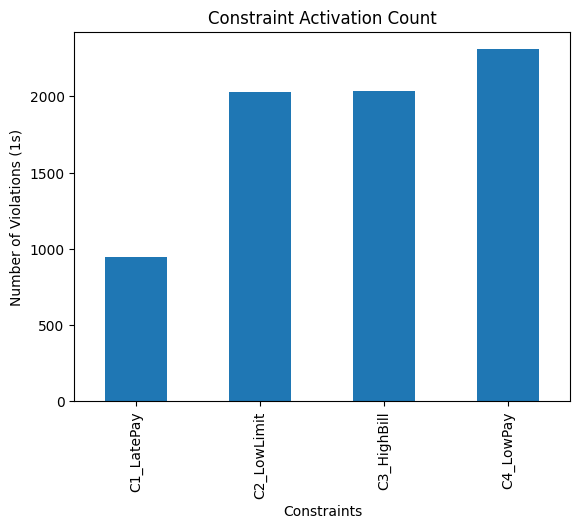

In [18]:
#CONSTRAINT ACTIVATION
import matplotlib.pyplot as plt

constraint_counts = df[['C1_LatePay','C2_LowLimit','C3_HighBill','C4_LowPay']].sum()

constraint_counts.plot(kind='bar')

plt.title("Constraint Activation Count")
plt.xlabel("Constraints")
plt.ylabel("Number of Violations (1s)")
plt.show()

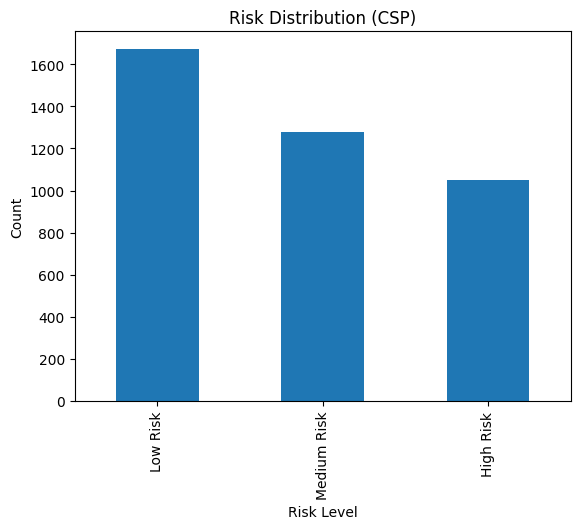

In [19]:
#RISK DISTRIBUTION
df['AI_Result'].value_counts().plot(kind='bar')

plt.title("Risk Distribution (CSP)")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

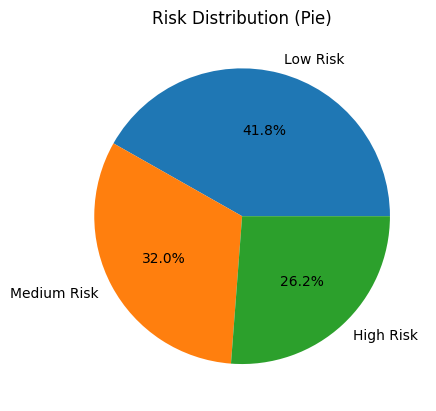

In [20]:
#PIE CHART
df['AI_Result'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Risk Distribution (Pie)")
plt.ylabel("")
plt.show()

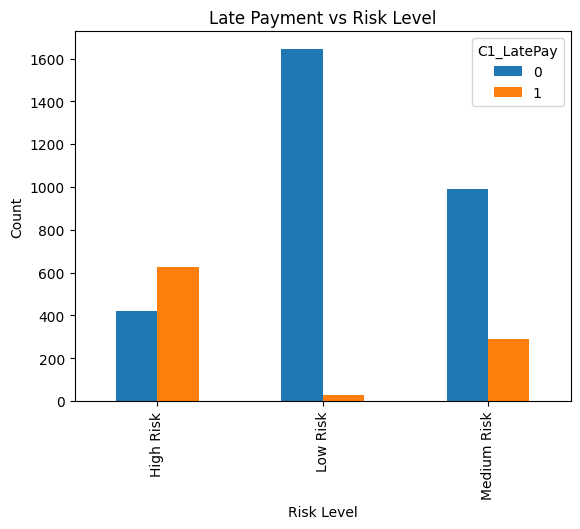

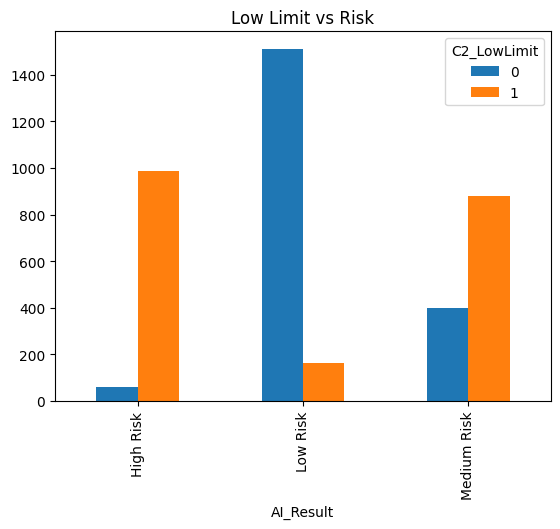

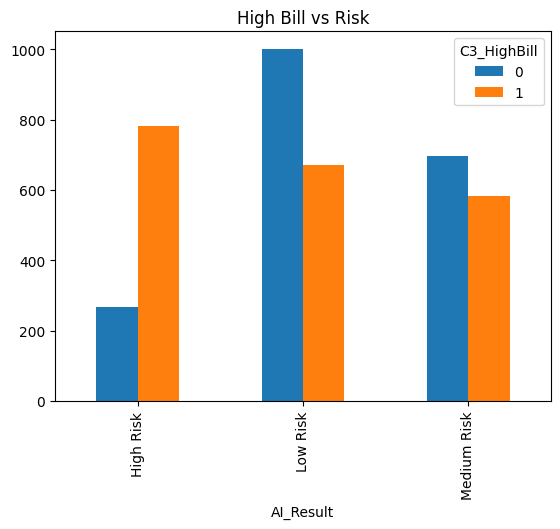

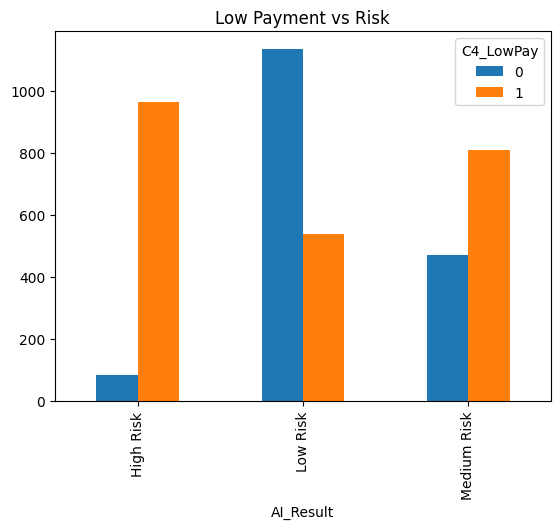

In [21]:
#CONSTRAINT vs RISK
import pandas as pd

constraint_vs_risk = pd.crosstab(df['AI_Result'], df['C1_LatePay'])

constraint_vs_risk.plot(kind='bar')

plt.title("Late Payment vs Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

pd.crosstab(df['AI_Result'], df['C2_LowLimit']).plot(kind='bar')
plt.title("Low Limit vs Risk")
plt.show()

pd.crosstab(df['AI_Result'], df['C3_HighBill']).plot(kind='bar')
plt.title("High Bill vs Risk")
plt.show()

pd.crosstab(df['AI_Result'], df['C4_LowPay']).plot(kind='bar')
plt.title("Low Payment vs Risk")
plt.show()

In [13]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


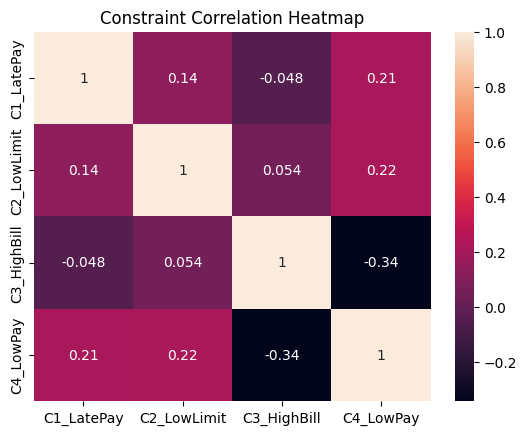

In [22]:
#HEATMAP

import seaborn as sns

sns.heatmap(df[['C1_LatePay','C2_LowLimit','C3_HighBill','C4_LowPay']].corr(), annot=True)

plt.title("Constraint Correlation Heatmap")
plt.show()